In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import deadwood
import sklearn as sk
import scipy
import itertools

import seaborn as sns
from deadwood import Deadwood
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
methods=['one-class-svm','isolation-forest','dbscan','lof','deadwood']

# Loader

In [4]:
import os
def load_all_datasets(directory):
    all_datasets = {}
    for root, dirs, files in os.walk(directory):
        for file in files:
            mat_data=scipy.io.loadmat(os.path.join(root,file))
            file_key = os.path.splitext(file)[0]
            df_x=pd.DataFrame(mat_data["X"])
            df_y=pd.DataFrame(mat_data["y"])

            duplicate_count = df_x.duplicated().sum()
            if duplicate_count > 0:
                print(f"Dataset '{file_key}' has {duplicate_count} duplicate rows (out of {df_x.shape[0]}. Removing them...")
                df_x_clean = df_x.drop_duplicates()
                df_y_clean = df_y.loc[df_x_clean.index]
                all_datasets[file_key]={
                    "X":df_x_clean.reset_index(drop=True),
                    "y":df_y_clean.reset_index(drop=True)
                }
            else:
                all_datasets[file_key]={
                    "X":pd.DataFrame(mat_data["X"]),
                    "y":pd.DataFrame(mat_data["y"])
                }
    return all_datasets


In [5]:
all_datasets = load_all_datasets("C:\\Users\\andrz\\Downloads\\dev_proj2_data")


Dataset 'annthyroid' has 138 duplicate rows (out of 7200. Removing them...
Dataset 'breastw' has 234 duplicate rows (out of 683. Removing them...
Dataset 'cardio' has 9 duplicate rows (out of 1831. Removing them...
Dataset 'glass' has 1 duplicate rows (out of 214. Removing them...
Dataset 'letter' has 2 duplicate rows (out of 1600. Removing them...
Dataset 'mammography' has 3335 duplicate rows (out of 11183. Removing them...
Dataset 'satimage-2' has 2 duplicate rows (out of 5803. Removing them...
Dataset 'thyroid' has 116 duplicate rows (out of 3772. Removing them...
Dataset 'vowels' has 4 duplicate rows (out of 1456. Removing them...


# Helper functions

In [6]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score


def get_unified_outlier_scores(model, X, method_name):
    if method_name == "isolation-forest":
        return -model.score_samples(X)

    elif method_name == "one-class-svm":
        return -model.score_samples(X)

    elif method_name == "lof":
        return -model.negative_outlier_factor_

    elif method_name == "dbscan":
        labels = model.labels_
        return np.where(labels == -1, 1.0, 0.0)
    elif method_name == "deadwood":
        labels = model.labels_
        return np.where(labels < 0, 1.0, 0.0)
    else:
        raise ValueError(f"Unknown method name: {method_name}")

def threshold_by_top_k(scores, contamination_rate):
    if contamination_rate <= 0 or contamination_rate >= 1:
        raise ValueError("Contamination rate must be between 0 and 1 exclusively.")

    n_samples = len(scores)
    k = int(np.ceil(contamination_rate * n_samples))
    threshold = np.partition(scores, -k)[-k]
    binary_preds = np.where(scores >= threshold, 1, 0)
    return binary_preds


def compute_evaluation_metrics(y_true, y_scores, y_pred=None, contamination=None):
    if y_pred is None:
        if contamination is None:
            raise ValueError("Must provide either 'y_pred' or a 'contamination' rate to calculate discrete metrics.")
        y_pred = threshold_by_top_k(y_scores, contamination)
    metrics = {
        "AUC-ROC": roc_auc_score(y_true, y_scores) if len(np.unique(y_true)) > 1 else np.nan,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

    return metrics, y_pred

In [7]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
def parse_method_default(method_name):
    if method_name == "isolation-forest":
        return IsolationForest()
    elif method_name == "one-class-svm":
        return OneClassSVM()
    elif method_name == "dbscan":
        return DBSCAN()
    elif method_name == "lof":
        return LocalOutlierFactor()
    elif method_name == "deadwood":
        return deadwood.Deadwood()
    else:
        raise ValueError(f"Unknown method name: {method_name}")


In [8]:
def extract_hyperparam_results_to_df(hyperparam_results):
    rows = []
    for method, datasets in hyperparam_results.items():
        for dataset_name, trials in datasets.items():
            for trial in trials:
                # Flatten the combined dictionary of parameters and metrics
                row = {
                    "method": method,
                    "dataset": dataset_name,
                    **trial
                }
                rows.append(row)
    return pd.DataFrame(rows)
def plot_metric_results(default_results, metric_name="AUC-ROC"):
    plot_data = []
    for method, datasets in default_results.items():
        for dataset, metrics in datasets.items():
            if metric_name in metrics:
                plot_data.append(
                    {
                        "Method": method,
                        "Dataset": dataset,
                        "Value": metrics[metric_name],
                    }
                )
    df = pd.DataFrame(plot_data)

    if df.empty:
        print(
            f"No data found for metric: '{metric_name}'. Please check your dictionary keys."
        )
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(
        data=df, x="Dataset", y="Value", hue="Method", palette="muted"
    )

    plt.title(f"Comparison of {metric_name} Across Datasets", fontsize=16, pad=15)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

# Performance evaluation at default hyperparams

In [14]:
default_results={
    method:{
        dataset:{}
        for dataset in all_datasets.keys()
    }
    for method in methods
}

In [18]:
for method in methods:
    for dataset in all_datasets.keys():
        model=parse_method_default(method)
        model.fit(all_datasets[dataset]["X"])
        scores=get_unified_outlier_scores(model, all_datasets[dataset]["X"], method)
        if method not in ['dbscan','deadwood']:
            preds=threshold_by_top_k(scores,np.mean(all_datasets[dataset]["y"])) #as y is binary vector of outlier indicators, its mean is the outlier ratio
        else:
            preds=scores
        default_results[method][dataset]=compute_evaluation_metrics(all_datasets[dataset]["y"],scores,y_pred=preds)[0]
        del model
        print(f"finished method {method} for dataset {dataset}")
    print(f"method {method} finished")

finished method one-class-svm for dataset annthyroid
finished method one-class-svm for dataset arrhythmia
finished method one-class-svm for dataset breastw
finished method one-class-svm for dataset cardio
finished method one-class-svm for dataset glass
finished method one-class-svm for dataset letter
finished method one-class-svm for dataset lympho
finished method one-class-svm for dataset mammography
finished method one-class-svm for dataset musk
finished method one-class-svm for dataset pendigits
finished method one-class-svm for dataset satellite
finished method one-class-svm for dataset satimage-2
finished method one-class-svm for dataset shuttle
finished method one-class-svm for dataset speech
finished method one-class-svm for dataset thyroid
finished method one-class-svm for dataset vertebral
finished method one-class-svm for dataset vowels
finished method one-class-svm for dataset wine
method one-class-svm finished
finished method isolation-forest for dataset annthyroid
finished

In [19]:
print(default_results)

{'one-class-svm': {'annthyroid': {'AUC-ROC': 0.5702270140265844, 'Accuracy': 0.8683092608326253, 'Precision': 0.12921348314606743, 'Recall': 0.12921348314606743, 'F1-Score': 0.12921348314606743}, 'arrhythmia': {'AUC-ROC': 0.7947872507457999, 'Accuracy': 0.8451327433628318, 'Precision': 0.4696969696969697, 'Recall': 0.4696969696969697, 'F1-Score': 0.4696969696969697}, 'breastw': {'AUC-ROC': 0.730325455558208, 'Accuracy': 0.7149220489977728, 'Precision': 0.7288135593220338, 'Recall': 0.7288135593220338, 'F1-Score': 0.7288135593220338}, 'cardio': {'AUC-ROC': 0.93530748547142, 'Accuracy': 0.9045005488474204, 'Precision': 0.5028571428571429, 'Recall': 0.5028571428571429, 'F1-Score': 0.5028571428571429}, 'glass': {'AUC-ROC': 0.4520697167755992, 'Accuracy': 0.9248826291079812, 'Precision': 0.1111111111111111, 'Recall': 0.1111111111111111, 'F1-Score': 0.1111111111111111}, 'letter': {'AUC-ROC': 0.5174032042723632, 'Accuracy': 0.886107634543179, 'Precision': 0.09, 'Recall': 0.09, 'F1-Score': 0.0

In [20]:
# #checkpoint saving
# import joblib
# joblib.dump(default_results,"result_dicts/default_values_metric_dict.joblib")

['result_dicts/default_values_metric_dict.joblib']

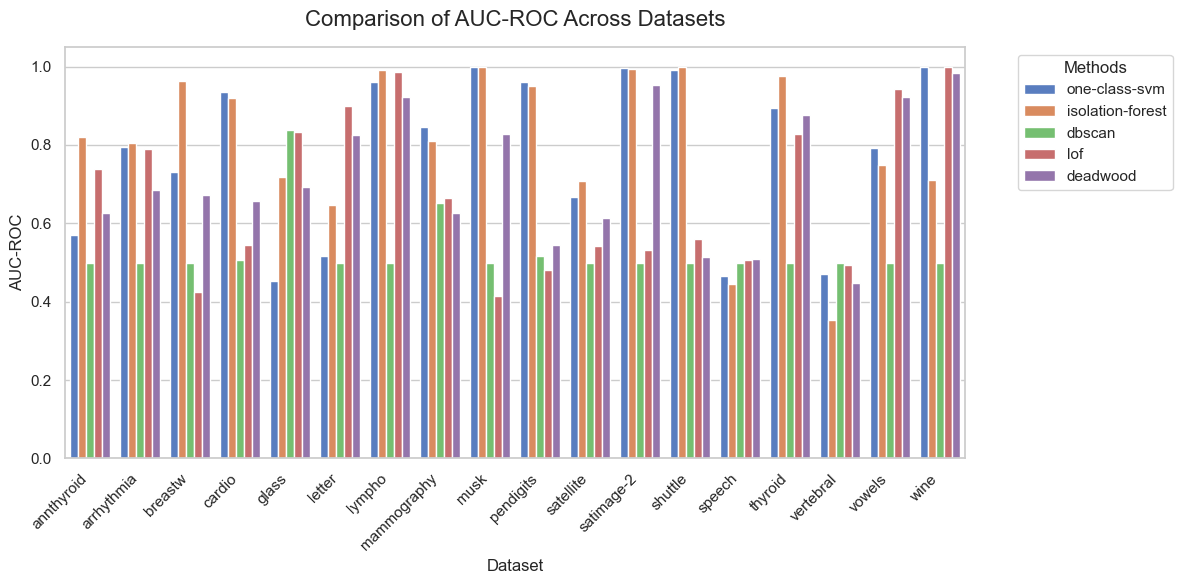

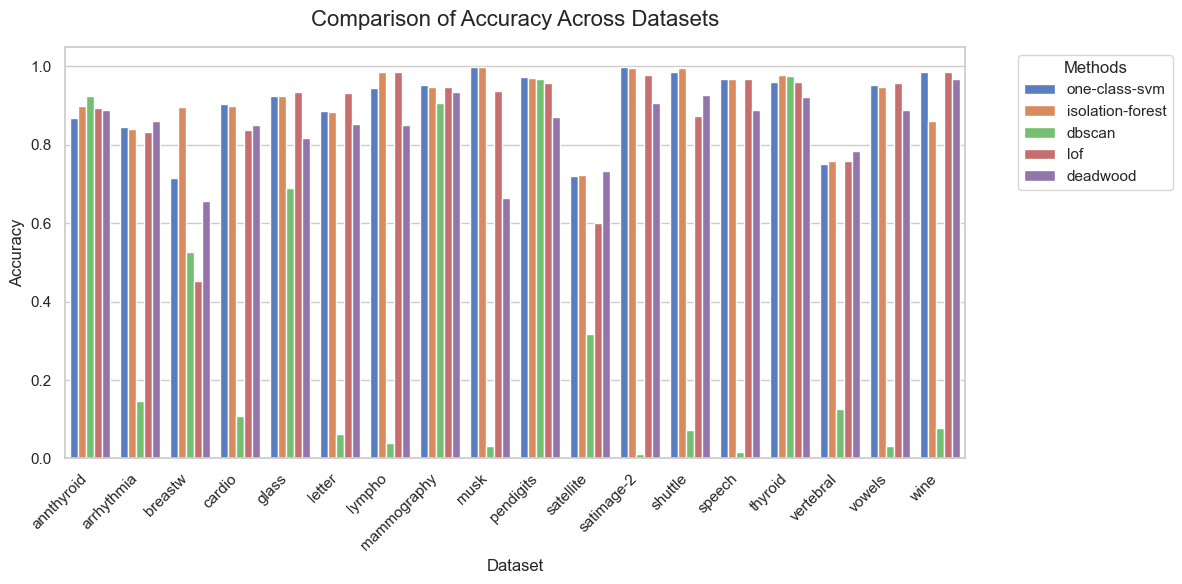

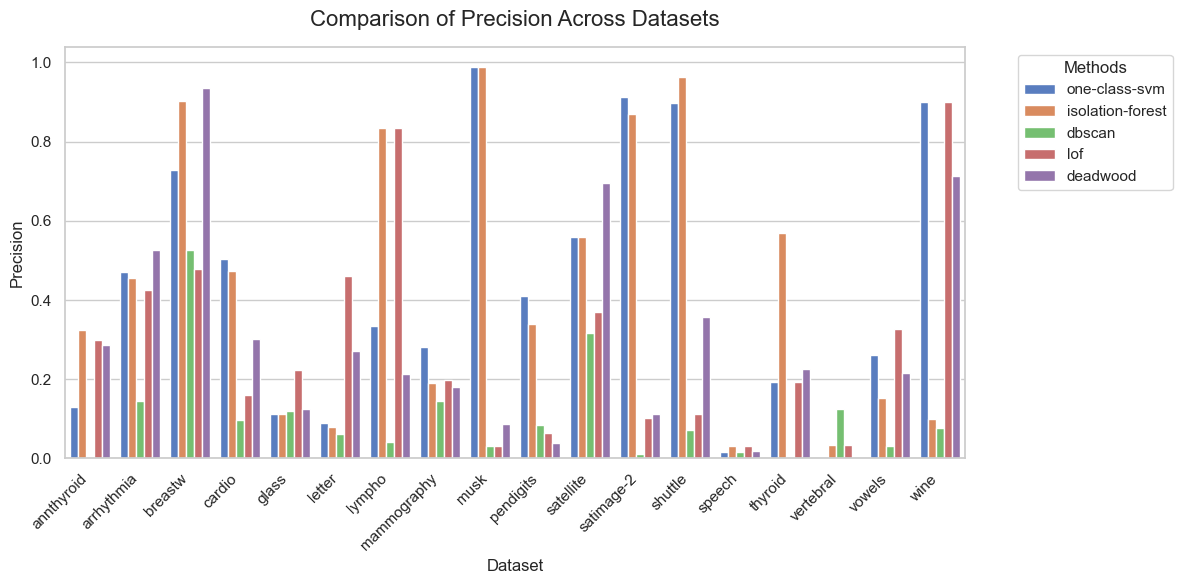

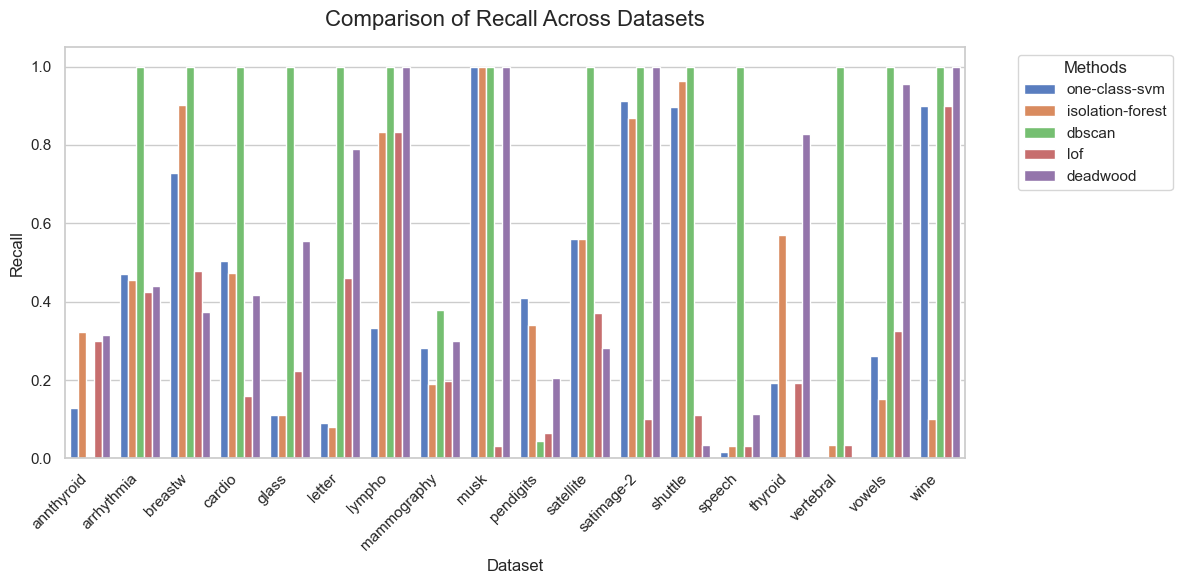

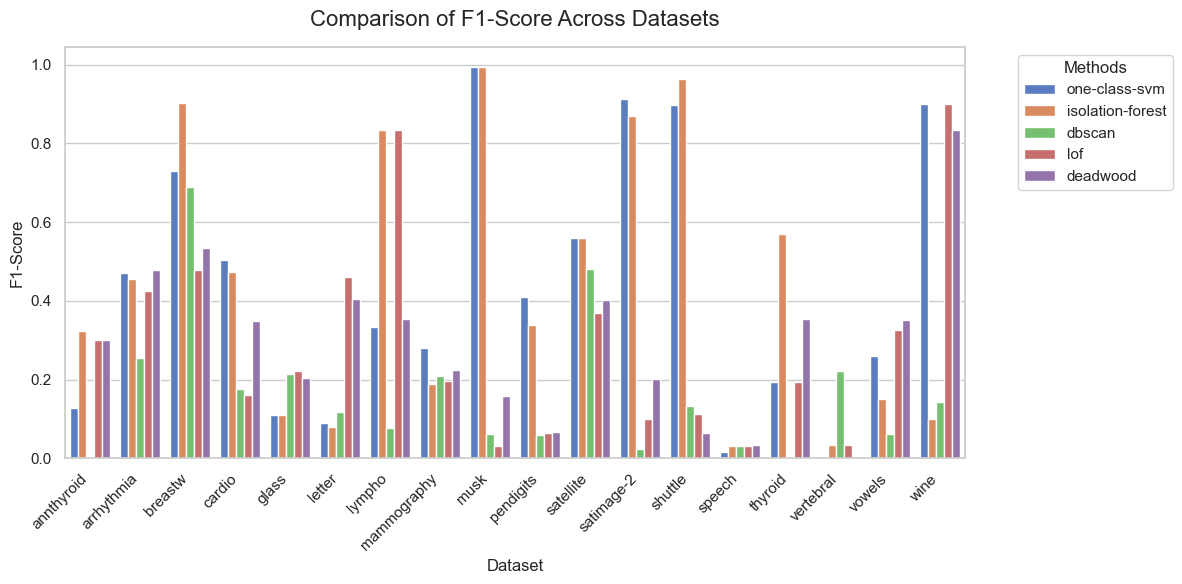

In [21]:
for metric in default_results['lof']['glass'].keys():
    plot_metric_results(default_results,metric)

In [9]:
param_grids = {
    "one-class-svm": {
        "nu": [0.001, 0.01, 0.05, 0.1, 0.15],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
        "shrinking": [True, False]
    },
    "isolation-forest": {
        "n_estimators": [100, 200, 300],
        "max_samples": ["auto", 0.5, 0.75],
        "max_features": [0.5, 0.8, 1.0],
    },
    "lof": {
        "n_neighbors": [5,10, 20, 35, 50],
        "metric": ["euclidean", "manhattan", "minkowski"],
        "leaf_size": [20, 30, 40]
    },
    "dbscan": {
    "eps": [0.1, 0.3, 0.5, 1.0, 3.0, 5.0],
    "min_samples": [3, 5, 10, 20, 50],
    "metric": ["euclidean", "manhattan", "cosine"],
    },
   "deadwood": {
        "M": [1, 5, 10, 20],
        "max_debris_size": [2, 5, 10, 15],
        "ema_dt": [0.01, 0.1, 0.5]
    }
}

# Hyperparameter influence

In [35]:
hyperparam_results = {
    method: {dataset: [] for dataset in all_datasets.keys()}
    for method in methods
}

In [10]:
#reloading partial dict if training had to be broken (not necessary if you run from start):
import joblib
hyperparam_results=joblib.load("result_dicts/hyperparam_optimization_metric_dict_tmp_after_satimage-2.joblib")
print(hyperparam_results)

{'one-class-svm': {'annthyroid': [{'nu': 0.001, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': True, 'AUC-ROC': 0.5995564482815597, 'Accuracy': 0.8751062022090059, 'Precision': 0.17415730337078653, 'Recall': 0.17415730337078653, 'F1-Score': 0.17415730337078653}, {'nu': 0.001, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': False, 'AUC-ROC': 0.5995564482815597, 'Accuracy': 0.8751062022090059, 'Precision': 0.17415730337078653, 'Recall': 0.17415730337078653, 'F1-Score': 0.17415730337078653}, {'nu': 0.001, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': True, 'AUC-ROC': 0.5971470634133803, 'Accuracy': 0.8683092608326253, 'Precision': 0.12921348314606743, 'Recall': 0.12921348314606743, 'F1-Score': 0.12921348314606743}, {'nu': 0.001, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': False, 'AUC-ROC': 0.5971470634133803, 'Accuracy': 0.8683092608326253, 'Precision': 0.12921348314606743, 'Recall': 0.12921348314606743, 'F1-Score': 0.12921348314606743}, {'nu': 0.001, 'kernel': 'linear', 'gamma': 'sc

In [39]:

import joblib
import time


for dataset_name, data in all_datasets.items():
    print("==============================")
    print(f"dataset_name: {dataset_name}")
    print("==============================")
    total_start_time = time.time()
    if hyperparam_results["one-class-svm"][dataset_name]!=[]:
        print(f"dataset {dataset_name} is already trained")
        continue
    X = data["X"]
    y = data["y"]
    contamination_rate = float(np.mean(y))
    start_time = time.time()
    one_model_time=start_time
    grid_svm = param_grids["one-class-svm"]
    keys, values = zip(*grid_svm.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        print(f"starting training for params: {params}. previous model took {time.time() - one_model_time:.2f} seconds")
        one_model_time=time.time()
        model = OneClassSVM(**params)
        model.fit(X)
        scores = get_unified_outlier_scores(model, X, "one-class-svm")
        preds = threshold_by_top_k(scores, contamination_rate)
        metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

        hyperparam_results["one-class-svm"][dataset_name].append({**params, **metrics})
    elapsed = time.time() - start_time
    print(f"finished svm for dataset {dataset_name} in {elapsed:.2f} seconds")
    start_time = time.time()
    one_model_time=start_time
    grid_if = param_grids["isolation-forest"]
    keys, values = zip(*grid_if.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        print(f"starting training for params: {params}. previous model took {time.time() - one_model_time:.2f} seconds")
        one_model_time=time.time()
        model = IsolationForest(**params, random_state=42,n_jobs=-1)
        model.fit(X)
        scores = get_unified_outlier_scores(model, X, "isolation-forest")
        preds = threshold_by_top_k(scores, contamination_rate)
        metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

        hyperparam_results["isolation-forest"][dataset_name].append({**params, **metrics})
    elapsed = time.time() - start_time
    print(f"finished forest for dataset {dataset_name} in {elapsed:.2f} seconds")
    start_time = time.time()
    one_model_time=start_time
    grid_lof = param_grids["lof"]
    keys, values = zip(*grid_lof.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        if params["n_neighbors"] < len(X):

            print(f"starting training for params: {params}. previous model took {time.time() - one_model_time:.2f} seconds")
            one_model_time=time.time()
            model = LocalOutlierFactor(n_neighbors=params["n_neighbors"], metric=params["metric"],n_jobs=-1)
            model.fit(X)
            scores = get_unified_outlier_scores(model, X, "lof")
            preds = threshold_by_top_k(scores, contamination_rate)
            metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

            hyperparam_results["lof"][dataset_name].append({**params, **metrics})
    elapsed = time.time() - start_time
    print(f"finished lof for dataset {dataset_name} in {elapsed:.2f} seconds")
    start_time = time.time()
    one_model_time=start_time
    grid_dbscan = param_grids["dbscan"]
    keys, values = zip(*grid_dbscan.items())
    for v in itertools.product(*values):
            params = dict(zip(keys, v))
            print(f"starting training for params: {params}. previous model took {time.time() - one_model_time:.2f} seconds")
            one_model_time=time.time()
            if params.get("min_samples", 5) <= len(X):
                model = DBSCAN(**params)
                model.fit(X)
                scores = get_unified_outlier_scores(model, X, "dbscan")
                preds = threshold_by_top_k(scores, contamination_rate)
                metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

                hyperparam_results["dbscan"][dataset_name].append({**params, **metrics})
    elapsed = time.time() - start_time
    print(f"finished dbscan for dataset {dataset_name} in {elapsed:.2f} seconds")
    start_time = time.time()
    one_model_time=start_time
    grid_deadwood = param_grids["deadwood"]
    keys, values = zip(*grid_deadwood.items())
    for v in itertools.product(*values):
            params = dict(zip(keys, v))
            print(f"starting training for params: {params}. previous model took {time.time() - one_model_time:.2f} seconds")
            one_model_time=time.time()
            if params.get("M", 1) <= len(X):
                model = deadwood.Deadwood(**params)
                model.fit(X)
                scores = get_unified_outlier_scores(model, X, "deadwood")
                preds = threshold_by_top_k(scores, contamination_rate)
                metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

                hyperparam_results["deadwood"][dataset_name].append({**params, **metrics})
    elapsed = time.time() - start_time
    print(f"finished deadwood for dataset {dataset_name} in {elapsed:.2f} seconds")
    print("========================================")
    print(f"dataset {dataset_name} finished")
    print("========================================")
    joblib.dump(hyperparam_results,f"result_dicts/hyperparam_optimization_metric_dict_tmp_after_{dataset_name}.joblib")

print("Continuous-score methods tuning completed successfully.")

dataset_name: annthyroid
dataset annthyroid is already trained
dataset_name: arrhythmia
dataset arrhythmia is already trained
dataset_name: breastw
dataset breastw is already trained
dataset_name: cardio
dataset cardio is already trained
dataset_name: glass
dataset glass is already trained
dataset_name: letter
dataset letter is already trained
dataset_name: lympho
dataset lympho is already trained
dataset_name: mammography
dataset mammography is already trained
dataset_name: musk
dataset musk is already trained
dataset_name: pendigits
dataset pendigits is already trained
dataset_name: satellite
dataset satellite is already trained
dataset_name: satimage-2
dataset satimage-2 is already trained
dataset_name: shuttle
starting training for params: {'nu': 0.001, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': True}. previous model took 0.00 seconds
starting training for params: {'nu': 0.001, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': False}. previous model took 0.52 seconds
starting tr

In [40]:
# #checkpoint saving
# import joblib
# joblib.dump(hyperparam_results,"result_dicts/hyperparam_optimization_metric_dict.joblib")

['result_dicts/hyperparam_optimization_metric_dict.joblib']

Analyzing sensitivity using target metric: 'AUC-ROC'

### HYPERPARAMETER SENSITIVITY SUMMARY PER ALGORITHM ###
| method           |   mean |    std |    min |    max |   range |
|:-----------------|-------:|-------:|-------:|-------:|--------:|
| dbscan           | 0.5246 | 0.076  | 0.3526 | 0.9417 |  0.5892 |
| deadwood         | 0.6923 | 0.118  | 0.4774 | 0.9547 |  0.4774 |
| isolation-forest | 0.861  | 0.1184 | 0.6183 | 1      |  0.3817 |
| lof              | 0.6447 | 0.1798 | 0.3176 | 0.9977 |  0.6801 |
| one-class-svm    | 0.5463 | 0.2556 | 0.0095 | 0.9964 |  0.9869 |


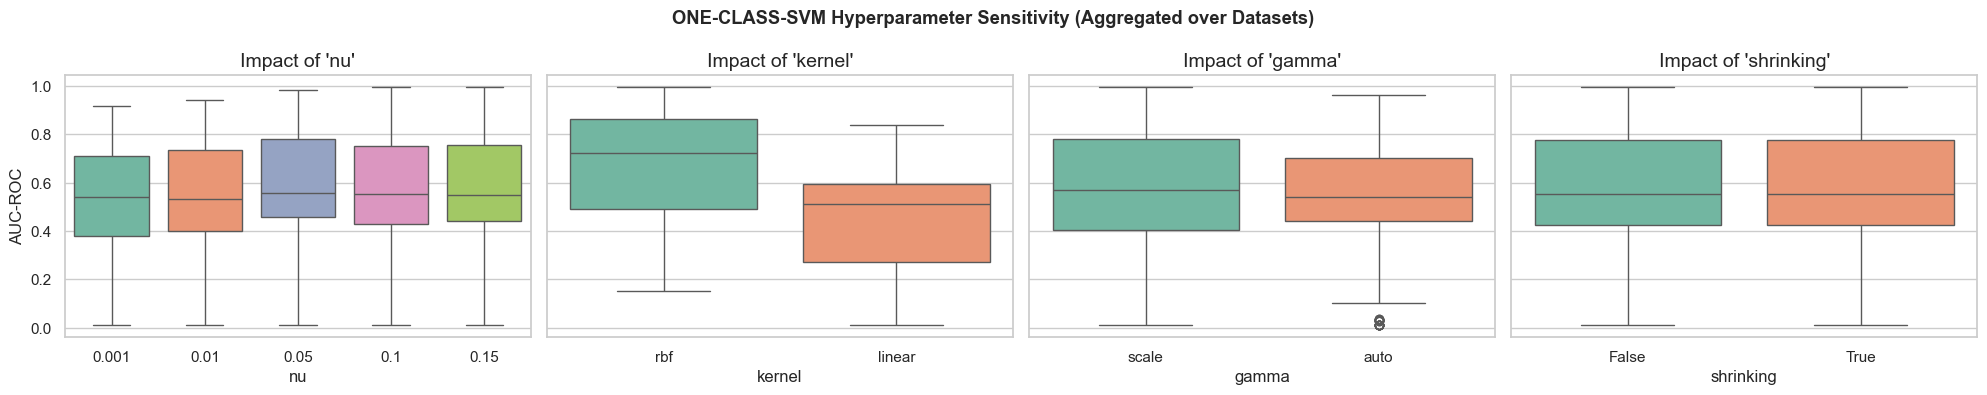

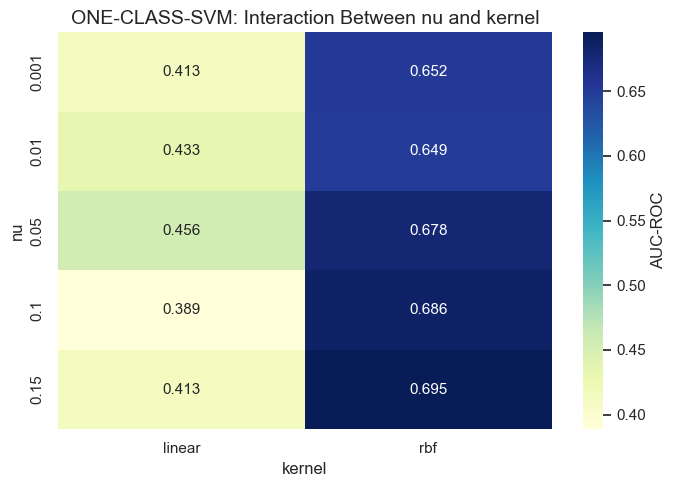

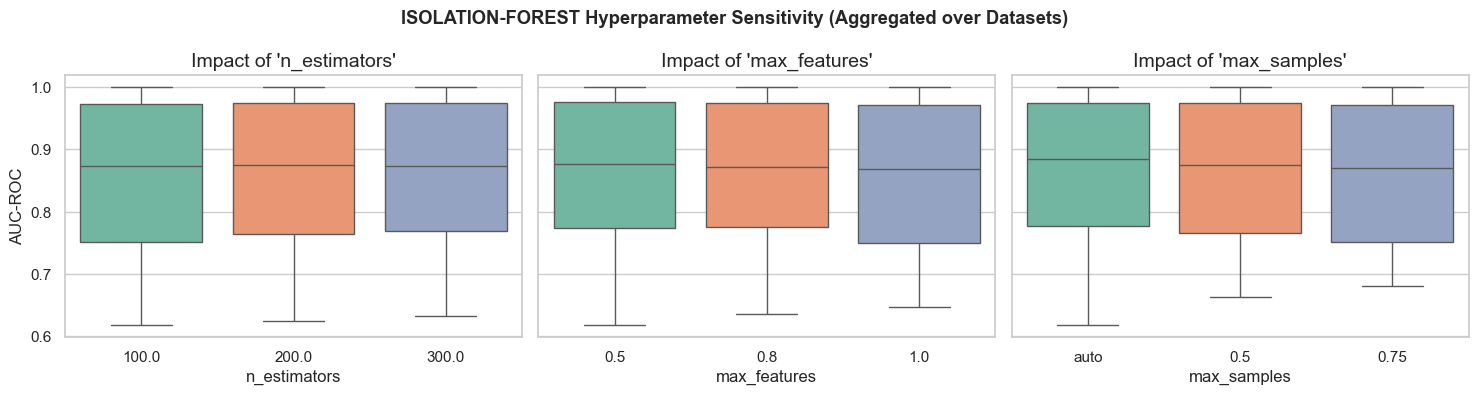

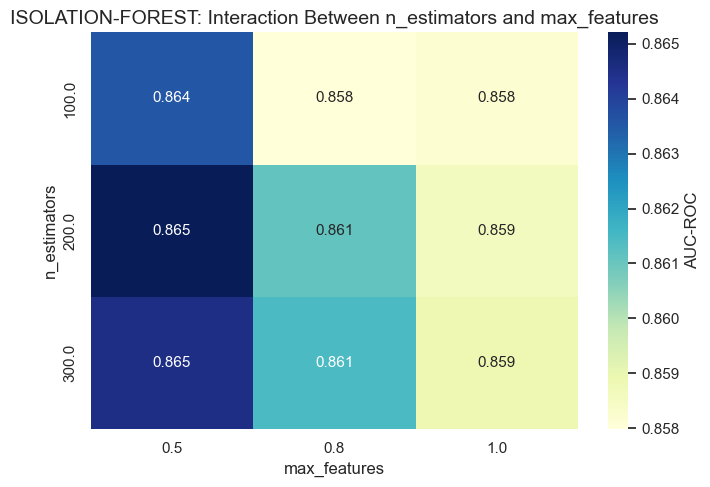

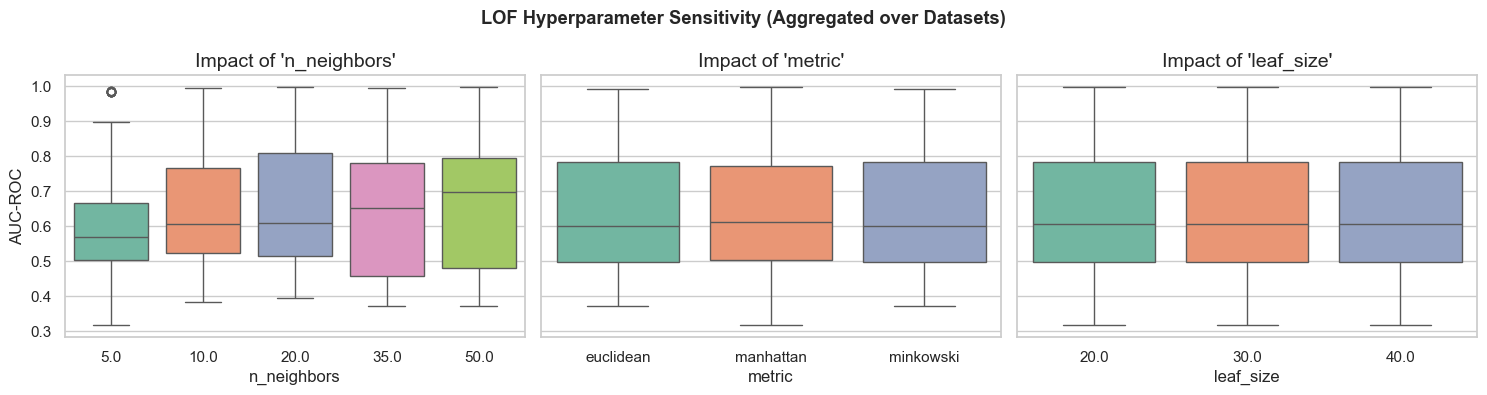

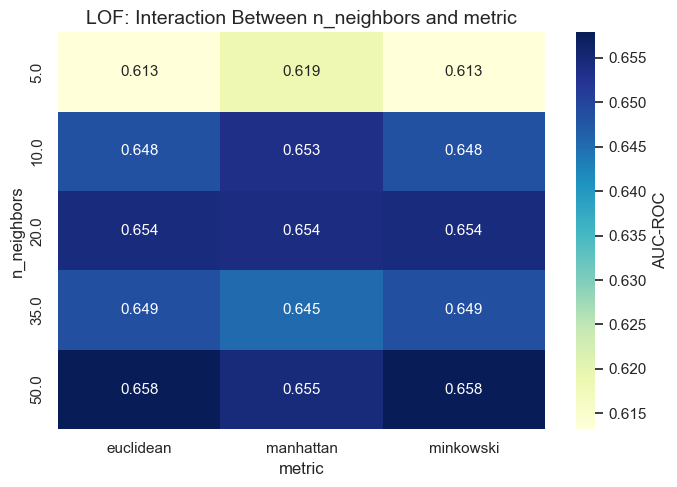

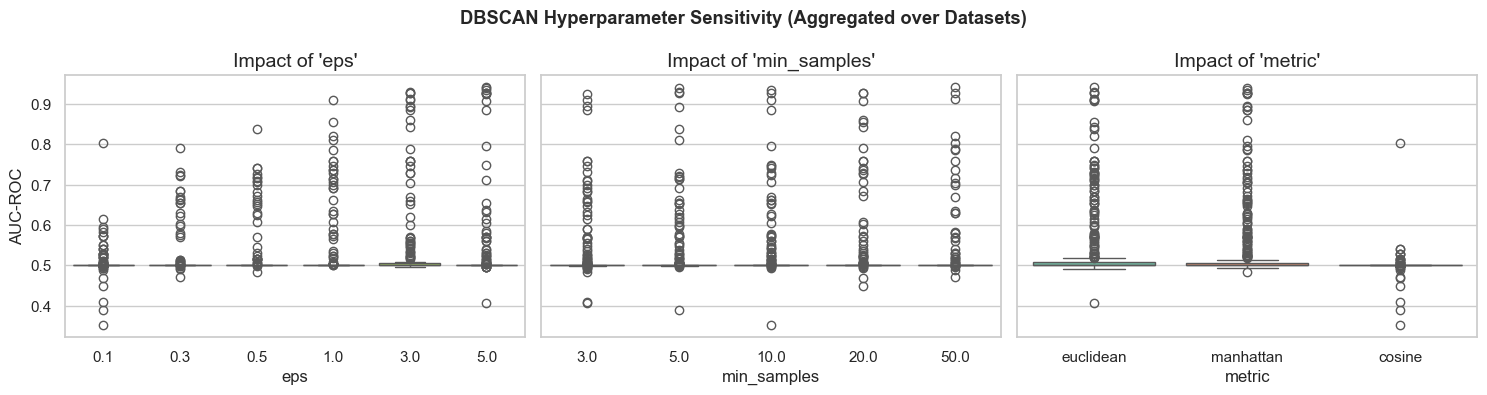

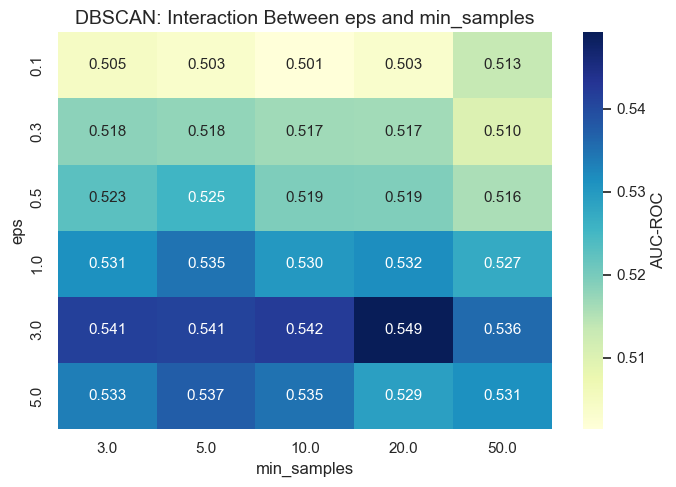

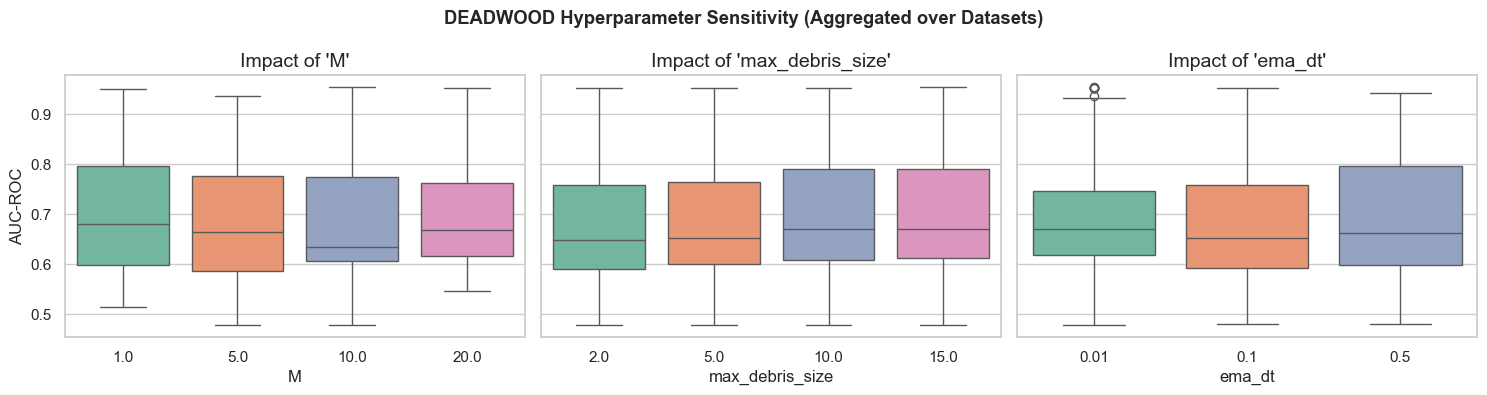

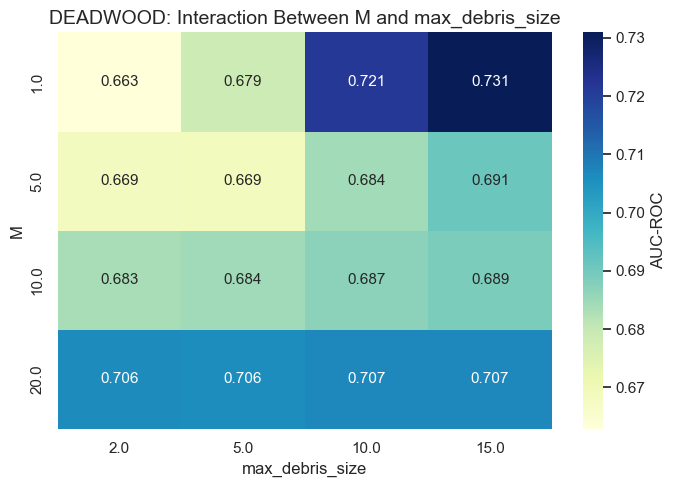

In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
df_results = extract_hyperparam_results_to_df(hyperparam_results)

metric_of_interest = 'AUC-ROC'



print(f"Analyzing sensitivity using target metric: '{metric_of_interest}'")
print("\n### HYPERPARAMETER SENSITIVITY SUMMARY PER ALGORITHM ###")
summary_stats = df_results.groupby('method')[metric_of_interest].agg(['mean', 'std', 'min', 'max'])
summary_stats['range'] = summary_stats['max'] - summary_stats['min']
print(summary_stats.round(4).to_markdown())

model_params = {
    "one-class-svm": ["nu", "kernel", "gamma","shrinking"],
    "isolation-forest": ["n_estimators", "max_features","max_samples"],
    "lof": ["n_neighbors", "metric","leaf_size"],
    "dbscan":["eps","min_samples","metric"],
    "deadwood":["M","max_debris_size","ema_dt"]
}

for method, params in model_params.items():
    df_method = df_results[df_results['method'] == method]

    if df_method.empty:
        continue

    num_params = len(params)
    fig, axes = plt.subplots(1, num_params, figsize=(5 * num_params, 4), sharey=True)
    if num_params == 1:
        axes = [axes]

    fig.suptitle(f'{method.upper()} Hyperparameter Sensitivity (Aggregated over Datasets)', weight='bold')

    for i, param in enumerate(params):
        sns.boxplot(
            data=df_method,
            x=param,
            y=metric_of_interest,
            ax=axes[i],
            palette="Set2"
        )
        axes[i].set_title(f"Impact of '{param}'")
        axes[i].set_xlabel(param)
        if i == 0:
            axes[i].set_ylabel(metric_of_interest)
        else:
            axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()

    if num_params >= 2:
        plt.figure(figsize=(7, 5))
        # Pivot table to find mean performance across the first two parameters
        piv = df_method.pivot_table(
            index=params[0],
            columns=params[1],
            values=metric_of_interest,
            aggfunc='mean'
        )
        sns.heatmap(piv, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': metric_of_interest})
        plt.title(f"{method.upper()}: Interaction Between {params[0]} and {params[1]}")
        plt.tight_layout()
        plt.show()

In [16]:
metrics=['AUC-ROC','Accuracy','Precision','Recall','F1-Score']
for metric_of_interest in metrics:
    print(f"\n### {metric_of_interest} PERFORMANCE PER METHOD PER DATASET ###")

    pivot_stats = (
        df_results.groupby(['method', 'dataset'])[metric_of_interest]
        .agg(['mean', 'std'])
        .round(4)
    )

    pivot_stats['mean ± std'] = pivot_stats.apply(lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}", axis=1)

    dataset_table = pivot_stats['mean ± std'].unstack(level='method')

    print(dataset_table.to_markdown())
    print("\n" + "="*50 + "\n")



### AUC-ROC PERFORMANCE PER METHOD PER DATASET ###
| dataset     | dbscan          | deadwood        | isolation-forest   | lof             | one-class-svm   |
|:------------|:----------------|:----------------|:-------------------|:----------------|:----------------|
| annthyroid  | 0.5038 ± 0.0132 | 0.5966 ± 0.0279 | 0.8075 ± 0.0207    | 0.7336 ± 0.0231 | 0.5605 ± 0.0454 |
| arrhythmia  | 0.5018 ± 0.0078 | 0.6560 ± 0.0481 | 0.8008 ± 0.0063    | 0.7597 ± 0.0700 | 0.5765 ± 0.1244 |
| breastw     | 0.5935 ± 0.1634 | 0.7807 ± 0.1036 | 0.9627 ± 0.0049    | 0.4254 ± 0.0425 | 0.3178 ± 0.3491 |
| cardio      | 0.5141 ± 0.0545 | 0.6265 ± 0.0361 | 0.9294 ± 0.0087    | 0.5849 ± 0.0609 | 0.5560 ± 0.3224 |
| glass       | 0.5595 ± 0.1033 | 0.7268 ± 0.0890 | 0.6999 ± 0.0092    | 0.7242 ± 0.1240 | 0.3277 ± 0.0746 |
| letter      | 0.5062 ± 0.0279 | 0.7639 ± 0.0465 | 0.6747 ± 0.0319    | 0.8814 ± 0.0249 | 0.5095 ± 0.0882 |
| lympho      | 0.5263 ± 0.0865 | 0.8483 ± 0.0616 | 0.9954 ± 0.0036    | 0.9

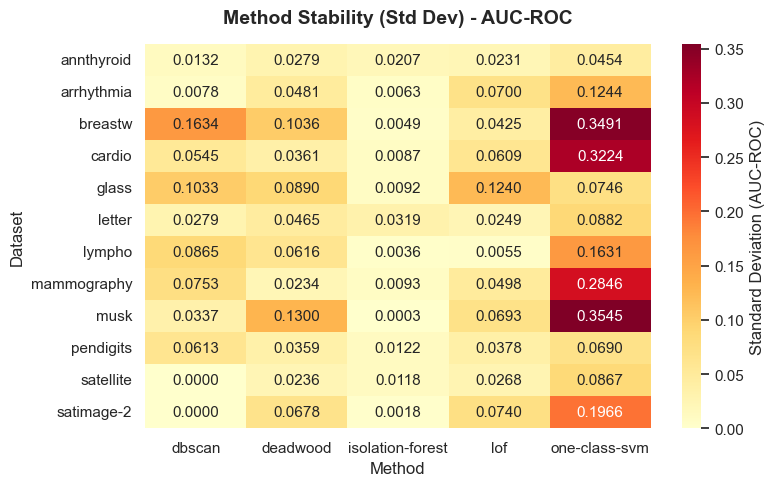

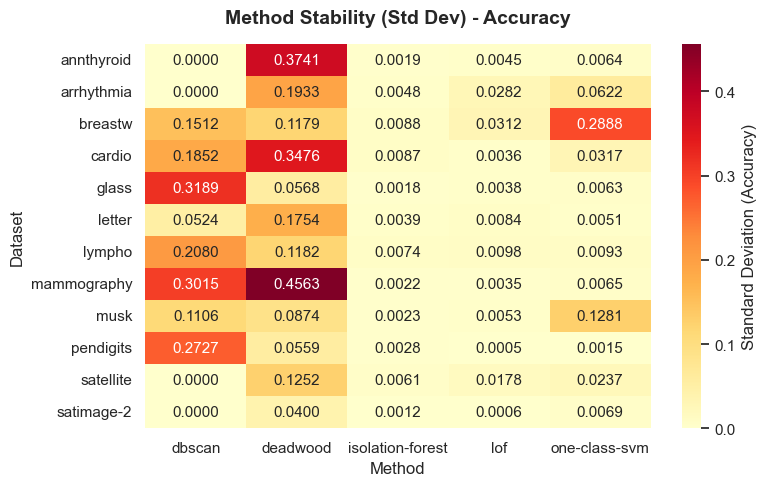

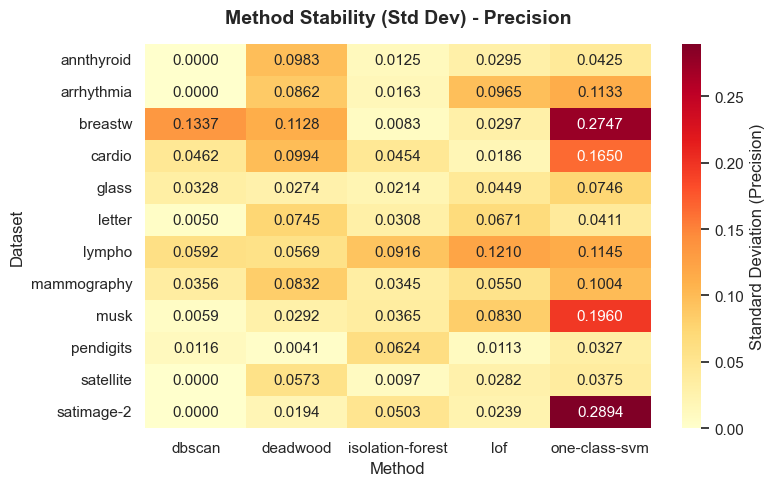

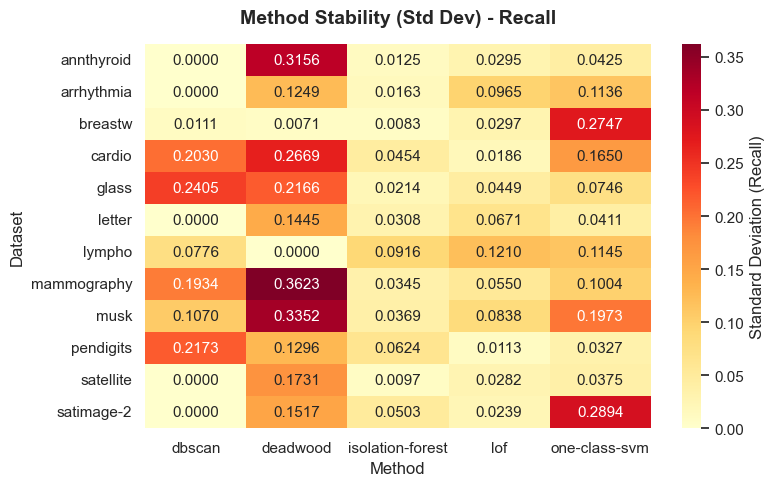

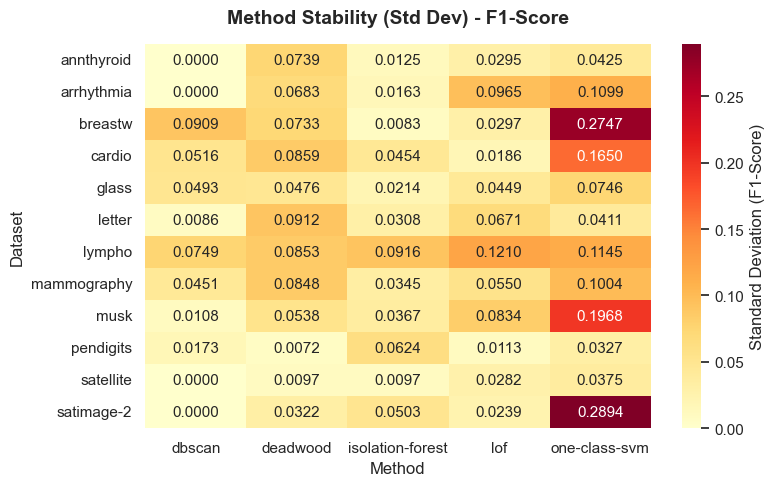

In [19]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

metrics = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric_of_interest in metrics:
    pivot_stats = (
        df_results.groupby(['method', 'dataset'])[metric_of_interest]
        .agg(['mean', 'std'])
        .round(4)
    )
    std_table = pivot_stats['std'].unstack(level='method')

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.heatmap(
        std_table,
        annot=True,
        cmap="YlOrRd",
        fmt=".4f",
        cbar_kws={'label': f'Standard Deviation ({metric_of_interest})'},
        ax=ax
    )

    ax.set_title(f"Method Stability (Std Dev) - {metric_of_interest}", weight='bold', pad=15)
    ax.set_xlabel("Method")
    ax.set_ylabel("Dataset")

    plt.tight_layout()

    safe_metric_name = metric_of_interest.lower().replace('-', '_')
    plt.show()
    plt.close()